In [55]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [56]:
X,y= make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

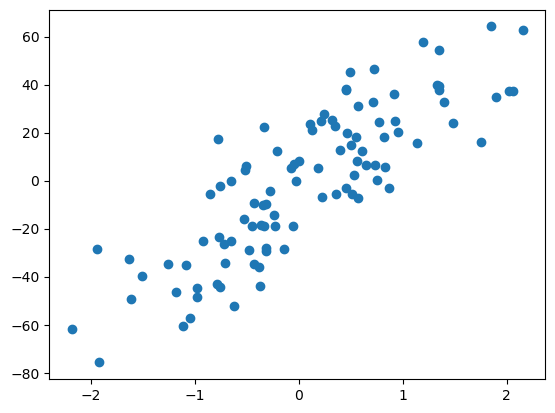

In [57]:
plt.scatter(X,y)

In [58]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=10)
ridge.fit(X,y)
print(ridge.coef_)
print(ridge.intercept_)


[24.9546267]
-2.1269130035235735


In [59]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=100)
ridge.fit(X,y)
print(ridge.coef_)
print(ridge.intercept_) # slope is decreasing with increase in alpha

[12.93442104]
-1.4248441496033308


In [60]:
class ridge:

    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,X_train,y_train):  # ORDINARY LEAST SQUARE METHOD - closed closure 
        num=0
        den=0

        for i in range(X_train.shape[0]):
            num = num + (X_train[i]-X_train.mean())*(y_train[i]-y_train.mean())
            den = den + (X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())

        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-(self.m*X_train.mean())
        print(self.m)
        print(self.b)

    def predict(self,x_test):
        return self.m*X_test+self.b


In [61]:
reg=ridge()
reg.fit(X,y)

[27.79608452]
[-2.29287514]


### Multiple feature Ridge Regression

In [62]:
from sklearn.datasets import load_diabetes

In [63]:
X,y=load_diabetes(return_X_y=True)

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [65]:
from sklearn.linear_model import Ridge

In [66]:
reg=Ridge(alpha=0.1,solver='cholesky')

In [67]:
reg.fit(X_train,y_train)


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [68]:
from sklearn.metrics import r2_score

In [69]:
y_pred=reg.predict(X_test)
r2_score(y_test,y_pred)

0.46931288533098037

In [70]:
reg.coef_

array([  44.02063391, -241.69329987,  452.98665299,  332.04420177,
        -76.33686744,  -68.52143809, -164.98809083,  149.96908118,
        431.61347417,   58.51862681])

In [71]:
reg.intercept_

np.float64(150.89053425602808)

In [72]:
class MRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None

    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        I=np.identity(X_train.shape[1])
        I[0][0]=0 # intercept should not get penalize bcoz The intercept just shifts the line up or down 
        betas=np.linalg.inv(np.dot(X_train.T,X_train)+self.alpha*I).dot(X_train.T).dot(y_train)
        self.intercept_=betas[0]
        self.coef_=betas[1:]

    def predict(self,X_test):
        y_pred=np.dot(X_test,self.coef_)+self.intercept_
        return y_pred

In [73]:
reg=MRidge()
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)


In [74]:
reg.coef_

array([  44.02063391, -241.69329987,  452.98665299,  332.04420177,
        -76.33686744,  -68.52143809, -164.98809083,  149.96908118,
        431.61347417,   58.51862681])

In [75]:
reg.intercept_

np.float64(150.8905342560281)

In [76]:
reg.alpha

0.1

### Ridge using gradient descent

In [77]:
from sklearn.datasets import load_diabetes
X,y=load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [78]:
# giant dataset-- use SGDRegressor(penalty='l2')
# smaller or sparse dataset-- you use Ridge(solver='sparse_cg'

In [79]:
from sklearn.linear_model import SGDRegressor


In [80]:
grad=SGDRegressor(penalty='l2',max_iter=100,eta0=0.1,learning_rate='constant',alpha=0.001)
# etatheta is learning rate
# learning rate can constant and can schedule 
# penalty l2 bcoz we r using sgd for ridge 
# alpha means lambda which is hyperparamter pf ridge reg

In [81]:
grad.fit(X_train,y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [82]:
y_pred=grad.predict(X_test)
y_pred

array([ 81.79379003, 114.91869877, 160.00491414,  55.90003785,
       165.44245416, 135.2325222 , 115.39627781, 117.12675021,
        78.35165528,  80.22298324,  94.1461067 , 177.43143121,
       166.1956985 , 132.05815815, 152.76690729, 139.69550924,
       182.68587714, 117.53783897, 103.98093377, 171.83335604,
       206.23541859, 170.89607548,  62.13980159, 204.51307137,
        67.77699947,  95.83161795, 152.79149943, 162.29717505,
        77.15384314,  84.25624788, 179.43118106, 106.96751131,
       221.11968443, 172.98876908, 102.41856938, 160.90480651,
       165.00052515, 157.0560432 , 143.467656  , 148.1264792 ,
       185.67350518, 164.46031892, 218.67495665,  75.20303972,
       210.8378856 , 104.52818539, 151.24221269,  76.13294704,
       175.93622467, 131.00948866, 113.4041933 , 103.18670914,
       154.32271033, 193.48648178,  62.31349314, 177.61626924,
        94.27471908,  92.53002059, 170.94556228, 199.76152838,
       126.22281455, 101.63889315, 156.4845658 , 222.69

In [83]:
r2_score(y_test,y_pred)

0.437378047323815

In [84]:
from sklearn.linear_model import Ridge
reg=Ridge(alpha=0.001,max_iter=100,solver='sparse_cg')


In [85]:
reg=MRidge()
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)

In [86]:
r2_score(y_test,y_pred)

0.46931288533098026

In [87]:
class MRidgeGD:
    def __init__(self,epochs,lr,alpha=0.1):
        self.epochs=epochs
        self.lr=lr
        self.alpha=alpha
        self.coef_=None
        self.intercept_=None

    def fit(self,X_train,y_train):

        self.coef_=np.ones(X_train.shape[1])
        self.intercept_= 0
        thetha=np.insert(self.coef_,0,self.intercept_)

        X_train=np.insert(X_train,0,1,axis=1)
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.lr*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]

    def predict(self,X_test):
        y_pred=np.dot(X_test,self.coef_)+self.intercept_
        return y_pred

In [88]:

reg = MRidgeGD(epochs=500,lr=0.005,alpha=0.001)

In [89]:

reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.47380182802609117
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713466


In [90]:
def cal_loss(m,alpha):
    return np.sum((y - (m*X.ravel() - 2.29))**2) + alpha*(m**2)

m = np.linspace(-45,100,100)

plt.figure(figsize=(4,6))

for j in [0,10,20,30,40,50,100]:

    loss = []

    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)

    plt.plot(m,loss,label='alpha = {}'.format(j))

plt.legend()
plt.xlabel('Slope (m)')
plt.ylabel('Loss')
plt.show()

ValueError: operands could not be broadcast together with shapes (442,) (4420,) 

<Figure size 400x600 with 0 Axes>